  Variable     Type                             Param  StartTime  EndTime
0      S_O     bias                   {'offset': 0.1}        4.0     4.10
1      S_O    drift                  {'slope': 0.001}        4.5     4.80
2      S_O  dropout                     {'freq': 0.1}        7.0     7.10
3      S_O    spike  {'freq': 0.05, 'magnitude': 0.2}        4.1     4.11
4      S_O    noise                {'magnitude': 0.2}        5.0     5.09
5      S_O  scaling                  {'factor': 1.11}        7.9     8.00
6      S_O    stuck                                {}        7.7     7.90


/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/matplotlib/cbook/__init__.py:1402: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x[:, None]
/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/matplotlib/axes/_base.py:276: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x = x[:, np.newaxis]
/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/matplotlib/axes/_base.py:278: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  y = y[:, np.newaxis]


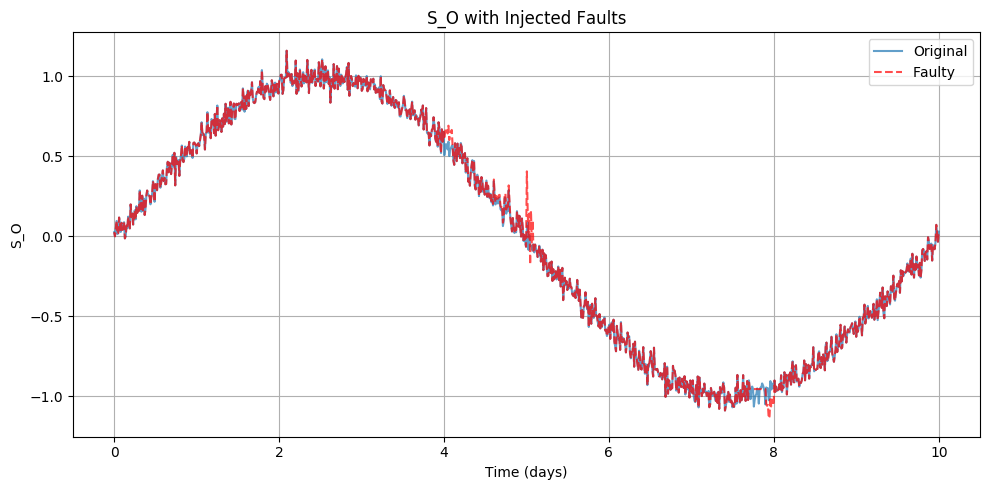

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def inject_faults(data, time, fault_config):
    data_faulty = data.copy()
    fault_log = []

    for cfg in fault_config:
        var = cfg['variable']
        t_start = cfg['t_start']
        t_end = cfg['t_end']
        fault_type = cfg['type']
        param = cfg.get('param', {})

        mask = (time >= t_start) & (time <= t_end)
        idx = np.where(mask)[0]
        if len(idx) == 0:
            continue

        x = data_faulty[var].values.copy()
        x_fault = x.copy()

        if fault_type == 'bias':
            x_fault[idx] = x[idx] + param['offset']

        elif fault_type == 'drift':
            drift = np.linspace(0, param['slope'] * len(idx), len(idx))
            x_fault[idx] = x[idx] + drift

        elif fault_type == 'stuck':
            x_fault[idx] = x[idx[0]]

        elif fault_type == 'spike':
            n_spikes = int(param['freq'] * len(idx))
            spike_idx = np.random.choice(idx, size=n_spikes, replace=False)
            x_fault[spike_idx] += param['magnitude'] * np.random.randn(n_spikes)

        elif fault_type == 'dropout':
            n_drop = int(param['freq'] * len(idx))
            drop_idx = np.random.choice(idx, size=n_drop, replace=False)
            x_fault[drop_idx] = np.nan

        elif fault_type == 'noise':
            x_fault[idx] = x[idx] + param['magnitude'] * np.random.randn(len(idx))

        elif fault_type == 'scaling':
            x_fault[idx] = x[idx] * param['factor']

        else:
            print(f"Warning: Unknown fault type '{fault_type}'")

        data_faulty[var] = x_fault

        fault_log.append({
            'Variable': var,
            'Type': fault_type,
            'Param': param,
            'StartTime': t_start,
            'EndTime': t_end
        })

    fault_log_df = pd.DataFrame(fault_log)
    return data_faulty, fault_log_df

# --- Example Usage ---

# Example DataFrame (replace with actual bsm1rainyr2 if available)
# Simulating some time-series data
np.random.seed(42)
timedays = np.linspace(0, 10, 1000)
bsm1rainyr2 = pd.DataFrame({
    'Timedays': timedays,
    'S_O': np.sin(2 * np.pi * timedays / 10) + 0.05 * np.random.randn(len(timedays))
})

# Define fault scenarios
faults = [
    {'variable': 'S_O', 'type': 'bias',    'param': {'offset': 0.1},     't_start': 4,   't_end': 4.1},
    {'variable': 'S_O', 'type': 'drift',   'param': {'slope': 0.001},    't_start': 4.5, 't_end': 4.8},
    {'variable': 'S_O', 'type': 'dropout', 'param': {'freq': 0.1},       't_start': 7,   't_end': 7.1},
    {'variable': 'S_O', 'type': 'spike',   'param': {'freq': 0.05, 'magnitude': 0.2}, 't_start': 4.1, 't_end': 4.11},
    {'variable': 'S_O', 'type': 'noise',   'param': {'magnitude': 0.2},  't_start': 5,   't_end': 5.09},
    {'variable': 'S_O', 'type': 'scaling', 'param': {'factor': 1.11},    't_start': 7.9, 't_end': 8},
    {'variable': 'S_O', 'type': 'stuck',   't_start': 7.7, 't_end': 7.9}
]

# Inject faults
data_faulty, fault_log = inject_faults(bsm1rainyr2, bsm1rainyr2['Timedays'], faults)

# Display fault log
print(fault_log)

# Plot
plt.figure(figsize=(10, 5))
plt.plot(bsm1rainyr2['Timedays'], bsm1rainyr2['S_O'], label='Original', alpha=0.7)
plt.plot(bsm1rainyr2['Timedays'], data_faulty['S_O'], 'r--', label='Faulty', alpha=0.7)
plt.title('S_O with Injected Faults')
plt.xlabel('Time (days)')
plt.ylabel('S_O')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Columns in data: Index(['Time [days]', 'S_I', 'S_S', 'X_I', 'X_S', 'X_BH', 'X_BA', 'X_P', 'S_O',
       'S_NO3', 'S_NH', 'S_ND', 'X_ND', 'S_ALK', 'S_NO2', 'S_NO', 'S_N2O',
       'S_N2', 'X_BA2', 'Temp', 'TSS_influent', 'Flow_influent', 'Kla',
       'S_I_reactor', 'S_S_reactor', 'X_I_reactor', 'X_S_reactor',
       'X_BH_reactor', 'X_BA_reactor', 'X_P_reactor', 'S_O_reactor',
       'S_NO3_reactor', 'S_NH_reactor', 'S_ND_reactor', 'X_ND_reactor',
       'S_ALK_reactor', 'S_NO2_reactor', 'S_NO_reactor', 'S_N2O_reactor',
       'S_N2_reactor', 'X_BA2_reactor', 'Temp_reactor'],
      dtype='object')
  Variable     Type                             Param  StartTime  EndTime
0      S_O     bias                   {'offset': 0.1}        4.0     4.10
1      S_O    drift                  {'slope': 0.001}        4.5     4.80
2      S_O  dropout                     {'freq': 0.1}        7.0     7.10
3      S_O    spike  {'freq': 0.05, 'magnitude': 0.2}        4.1     4.11
4      S_O    noise      

/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/matplotlib/cbook/__init__.py:1402: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x[:, None]
/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/matplotlib/axes/_base.py:276: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x = x[:, np.newaxis]
/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/matplotlib/axes/_base.py:278: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  y = y[:, np.newaxis]


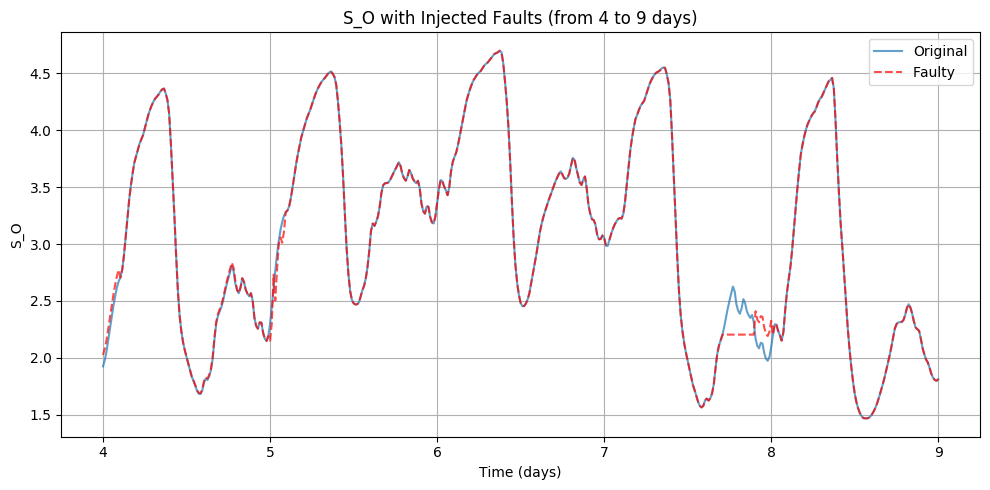

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def inject_faults(data, time, fault_config):
    data_faulty = data.copy()
    fault_log = []

    for cfg in fault_config:
        var = cfg['variable']
        t_start = cfg['t_start']
        t_end = cfg['t_end']
        fault_type = cfg['type']
        param = cfg.get('param', {})

        mask = (time >= t_start) & (time <= t_end)
        idx = np.where(mask)[0]
        if len(idx) == 0:
            continue

        x = data_faulty[var].values.copy()
        x_fault = x.copy()

        if fault_type == 'bias':
            x_fault[idx] = x[idx] + param['offset']
        elif fault_type == 'drift':
            drift = np.linspace(0, param['slope'] * len(idx), len(idx))
            x_fault[idx] = x[idx] + drift
        elif fault_type == 'stuck':
            x_fault[idx] = x[idx[0]]
        elif fault_type == 'spike':
            n_spikes = int(param['freq'] * len(idx))
            spike_idx = np.random.choice(idx, size=n_spikes, replace=False)
            x_fault[spike_idx] += param['magnitude'] * np.random.randn(n_spikes)
        elif fault_type == 'dropout':
            n_drop = int(param['freq'] * len(idx))
            drop_idx = np.random.choice(idx, size=n_drop, replace=False)
            x_fault[drop_idx] = np.nan
        elif fault_type == 'noise':
            x_fault[idx] = x[idx] + param['magnitude'] * np.random.randn(len(idx))
        elif fault_type == 'scaling':
            x_fault[idx] = x[idx] * param['factor']
        else:
            print(f"Warning: Unknown fault type '{fault_type}'")

        data_faulty[var] = x_fault

        fault_log.append({
            'Variable': var,
            'Type': fault_type,
            'Param': param,
            'StartTime': t_start,
            'EndTime': t_end
        })

    fault_log_df = pd.DataFrame(fault_log)
    return data_faulty, fault_log_df

# --- Load CSV file ---
file_path = 'data/bsm1-rainy-r1.csv'
df = pd.read_csv(file_path)

# Check the columns
print("Columns in data:", df.columns)

# Select column to inject faults into, e.g., 'S_O'
time_col = 'Time [days]'
target_col = 'S_O'

# Define faults for the selected column
faults = [
    {'variable': target_col, 'type': 'bias',    'param': {'offset': 0.1},     't_start': 4,   't_end': 4.1},
    {'variable': target_col, 'type': 'drift',   'param': {'slope': 0.001},    't_start': 4.5, 't_end': 4.8},
    {'variable': target_col, 'type': 'dropout', 'param': {'freq': 0.1},       't_start': 7,   't_end': 7.1},
    {'variable': target_col, 'type': 'spike',   'param': {'freq': 0.05, 'magnitude': 0.2}, 't_start': 4.1, 't_end': 4.11},
    {'variable': target_col, 'type': 'noise',   'param': {'magnitude': 0.2},  't_start': 5,   't_end': 5.09},
    {'variable': target_col, 'type': 'scaling', 'param': {'factor': 1.11},    't_start': 7.9, 't_end': 8},
    {'variable': target_col, 'type': 'stuck',   't_start': 7.7, 't_end': 7.9}
]

# Inject faults
data_faulty, fault_log = inject_faults(df, df[time_col], faults)

# Display fault log
print(fault_log)

# Plot results
plot_start, plot_end = 4, 9
plot_mask = (df[time_col] >= plot_start) & (df[time_col] <= plot_end)

plt.figure(figsize=(10, 5))
plt.plot(df[time_col][plot_mask], df[target_col][plot_mask], label='Original', alpha=0.7)
plt.plot(df[time_col][plot_mask], data_faulty[target_col][plot_mask], 'r--', label='Faulty', alpha=0.7)
plt.title(f"{target_col} with Injected Faults (from {plot_start} to {plot_end} days)")
plt.xlabel("Time (days)")
plt.ylabel(target_col)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()